Features selected: 48 / 60
Before ADASYN: {np.int64(0): np.int64(986), np.int64(1): np.int64(190)}
After  ADASYN: {np.int64(0): np.int64(986), np.int64(1): np.int64(1013)}


Threshold: 0.489
Accuracy  : 0.8299
Precision : 0.4746
Recall    : 0.5957
F1-Score  : 0.5283
ROC-AUC   : 0.8402
              precision    recall  f1-score   support

No Attrition       0.92      0.87      0.90       247
   Attrition       0.47      0.60      0.53        47

    accuracy                           0.83       294
   macro avg       0.70      0.74      0.71       294
weighted avg       0.85      0.83      0.84       294

5-Fold CV F1: 0.3817 ± 0.1145


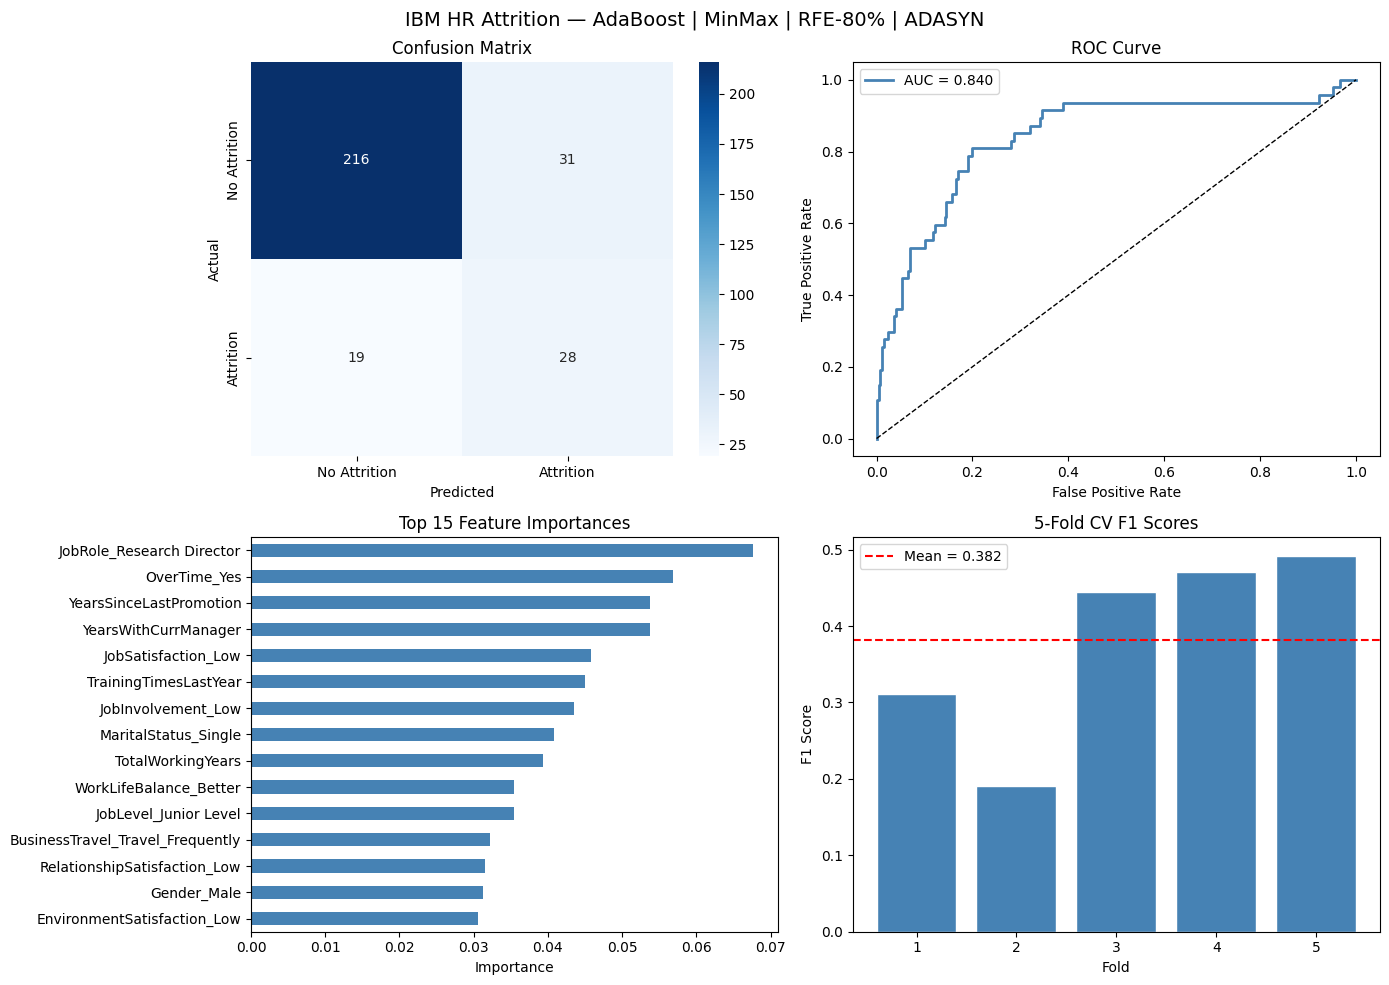

In [23]:
"""
IBM HR Employee Attrition Prediction
=====================================
Model              : AdaBoost
Scaler             : MinMaxScaler
Feature Selection  : Recursive Feature Elimination (RFE) - 80%
Data Balancing     : ADASYN

NOTE: Assumes X (features) and y (target) are already prepared and cleaned.
      y should be binary encoded: 1 = Attrition, 0 = No Attrition
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import ADASYN
df = pd.read_csv('../data/Processed_HR_Employee_Attrition.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True) # drop_first avoids multicollinearity
X = df.drop('Attrition', axis=1)
y = df['Attrition']
# ─── 1. TRAIN / TEST SPLIT ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ─── 2. MINMAX SCALING ───────────────────────────────────────────────────────
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ─── 3. RFE - 80% FEATURE SELECTION ─────────────────────────────────────────
n_select = int(np.ceil(X_train_scaled.shape[1] * 0.80))

rfe = RFE(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_features_to_select=n_select
)
rfe.fit(X_train_scaled, y_train)

X_train_rfe = X_train_scaled[:, rfe.support_]
X_test_rfe  = X_test_scaled[:, rfe.support_]

print(f"Features selected: {n_select} / {X_train_scaled.shape[1]}")

# ─── 4. ADASYN BALANCING ─────────────────────────────────────────────────────
adasyn = ADASYN(random_state=42)
X_train_bal, y_train_bal = adasyn.fit_resample(X_train_rfe, y_train)

print(f"Before ADASYN: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"After  ADASYN: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}")

# ─── 5. ADABOOST ─────────────────────────────────────────────────────────────
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train_bal, y_train_bal)

# ─── 6. EVALUATION ───────────────────────────────────────────────────────────
# y_pred = ada.predict(X_test_rfe)
y_prob = ada.predict_proba(X_test_rfe)[:, 1]
threshold = 0.489   # <-- change this value (default is 0.5)

y_pred = (y_prob >= threshold).astype(int)

print("\n" + "="*45)
print(f"\nThreshold: {threshold}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print("="*45)
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

cv_scores = cross_val_score(ada, X_train_rfe, y_train,
                             cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                             scoring='f1')
print(f"5-Fold CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ─── 7. PLOTS ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('IBM HR Attrition — AdaBoost | MinMax | RFE-80% | ADASYN', fontsize=14)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0, 0], cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0, 1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}', color='steelblue', lw=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_title('ROC Curve')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend()

# Feature Importances
feature_names = X.columns[rfe.support_].tolist() if hasattr(X, 'columns') else [f'f{i}' for i in range(X_train_rfe.shape[1])]
fi = pd.Series(ada.feature_importances_, index=feature_names).sort_values(ascending=True).tail(15)
fi.plot(kind='barh', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Top 15 Feature Importances')
axes[1, 0].set_xlabel('Importance')

# CV Scores
axes[1, 1].bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
axes[1, 1].axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
axes[1, 1].set_title('5-Fold CV F1 Scores')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('ibm_attrition_results.png', dpi=150, bbox_inches='tight')
plt.show()